<a href="https://colab.research.google.com/github/smacha326/Behind_The_ED_Visits_Disparities/blob/main/Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BUAN 6382 - Deep Learning
## Project 1

#### Sairamya Macha, Emma Hockett, Shreyam Misra

# Step 0: Imports and Setup


In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from torch.utils.data import random_split, DataLoader
import pandas as pd
from pathlib import Path
import random
import copy
import torch.nn as nn
import torch.nn.functional as F


print("PyTorch version:", torch.__version__)

PyTorch version: 2.10.0+cu128


In [ ]:
pip install torchviz

In [ ]:
# If in Colab, then import the drive module from google.colab
if 'google.colab' in str(get_ipython()):
  from google.colab import drive
  # Mount the Google Drive to access files stored there
  drive.mount('/content/drive')

  # Install the latest version of torchtext library quietly without showing output

  !pip install torchinfo -qq

  basepath = '/content/drive/MyDrive/Colab Notebooks'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Setting up the paths for the folders
base_folder = Path(basepath)
data_folder = base_folder / 'Data'
model_folder = base_folder / 'Models'

# If the model and data folder do not exist then make them
model_folder.mkdir(parents=True, exist_ok=True)
data_folder.mkdir(parents=True, exist_ok=True)

In [ ]:
# Introducing a seed for reproducible results
seed = 42

torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Step 1: Dataset Exploration and Preprocessing

## 1.1 Loading the Data

In [ ]:
# Load CIFAR-10 dataset
transform = transforms.ToTensor()

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

print("Training samples:", len(trainset))
print("Test samples:", len(testset))

Training samples: 50000
Test samples: 10000


## 1.2 Explore the Dataset

### 1.2.1 Dataset Classes

In [ ]:
# Target classes:
classes = trainset.classes
for i in range(0,10):
    print(f"{i}: {classes[i]}")

0: airplane
1: automobile
2: bird
3: cat
4: deer
5: dog
6: frog
7: horse
8: ship
9: truck


As shown above there are a total of 10 classes in the dataset. These will be the class labels or targets that will the CNN will predict later.

### 1.2.2 First 5 Items in Dataset

In [ ]:
# Looking at the first 5 instances in the dataset
for i in range(5):
    image, label = trainset[i]
    print(i, label, image.shape)

0 6 torch.Size([3, 32, 32])
1 9 torch.Size([3, 32, 32])
2 9 torch.Size([3, 32, 32])
3 4 torch.Size([3, 32, 32])
4 1 torch.Size([3, 32, 32])


From this we are able to determine a few things. First the dataset is not in order. We are able to conclude this by the mixed ordering of the target classes (column 2). Secondly, we can confirm that these are 32x32 images from the shape of the image tensors. Also the fact that this is a 3 dimentional tensor with 3 layers indicates the split of RBG for the images.

### 1.2.3 Image Visualization Example for Each Class

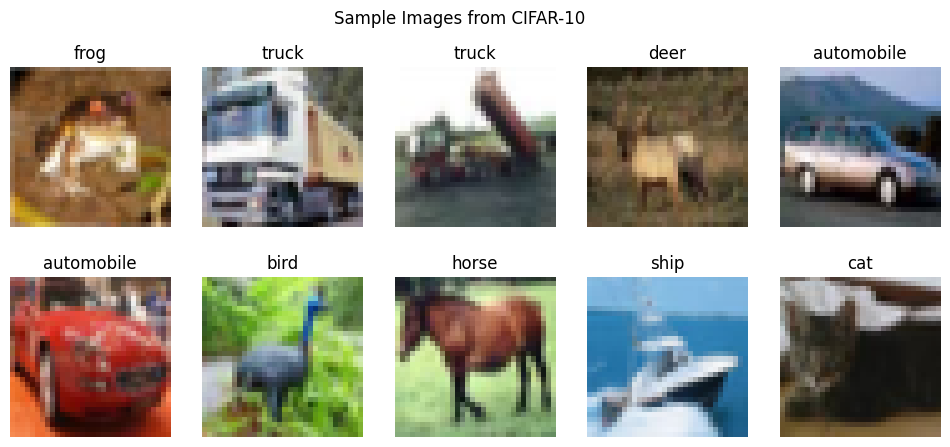

In [ ]:
# Showing the first 10 images just to see what they look like
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    image, label = trainset[i]
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(classes[label])
    ax.axis('off')

plt.suptitle('Sample Images from CIFAR-10')
plt.show()

The above image shows an example of each of the 10 classes. As shown, the images are generally really blurry because of the 32x32 pixel nature of the dataset. In total there is only 1024 pixels in the entire image, explaining the lower quality than most images.

### 1.2.4 Pixel Distribution

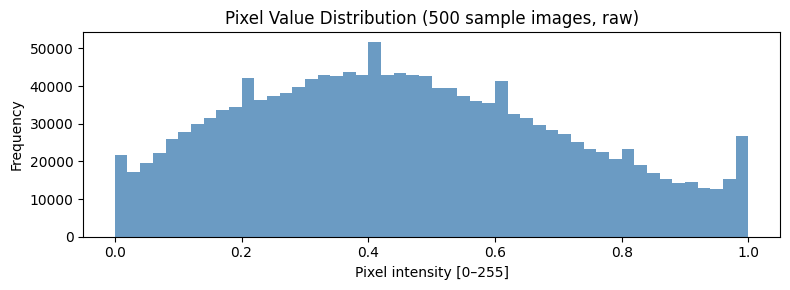

Mean : 0.46
Std  : 0.25
Range: 0.0 – 1.0


In [ ]:
# Pixel value distribution (raw, 500 random images)
sample_ids = np.random.choice(len(trainset), 500, replace=500)
pixels = np.concatenate([
    trainset[i][0].numpy().flatten()
    for i in sample_ids
])

plt.figure(figsize=(8, 3))
plt.hist(pixels, bins=50, color='steelblue', alpha=0.8, edgecolor='none')
plt.title('Pixel Value Distribution (500 sample images, raw)')
plt.xlabel('Pixel intensity [0–255]')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f'Mean : {pixels.mean():.2f}')
print(f'Std  : {pixels.std():.2f}')
print(f'Range: {pixels.min()} – {pixels.max()}')

The above histogram shows approximately how the pixel values are distributed. There is a very rough normal distribution shape, however there are peaks at the highest and lowest values. This menas that the majority of the pixels are near the middle in terms of intensity.

### 1.2.5 Cosine Similarity Between Classes

In [ ]:
# Calculating the average image details for each class
num_classes = 10
class_sums = torch.zeros(num_classes, 3, 32, 32)
class_counts = torch.zeros(num_classes)

for img, label in trainset:
    class_sums[label] += img
    class_counts[label] += 1

class_means = class_sums / class_counts[:, None, None, None]

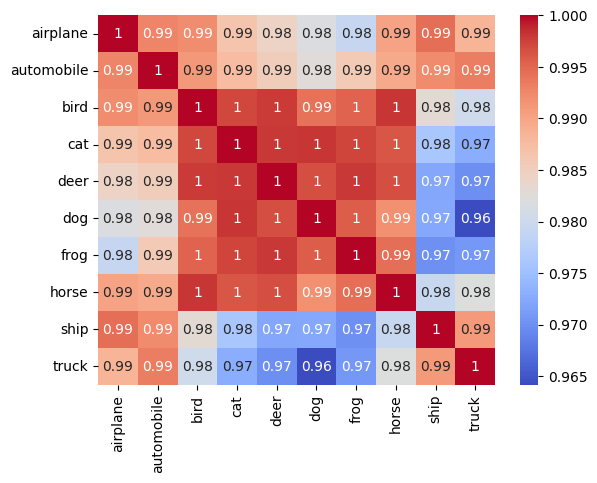

In [ ]:
# Visualizing a heat map of the similarity between classes
flattened = class_means.view(num_classes, -1)
similarity_matrix = cosine_similarity(flattened)

sns.heatmap(similarity_matrix,
            xticklabels=classes,
            yticklabels=classes,
            annot= True,
            cmap="coolwarm")
plt.show()

By computing a cosine similarity heatmap using the between class-average images, we are able to get a better view of some details. At first glance, we are able to see that all of the averages of the classes are very similar (smallest score being 0.96). This is to be expected because of the nature of data and the limited pixel amounts. However, when we look closer we are able to see some loose clusters. The clusters are animals (bird, cat, deer, dog, frog, horse) and vehicles (airplane, automobile, ship, truck). In the middle of the heatmap there are higher similarites within the animal cluster. Similarly, the vehicles tend to have higher similarites, as seen in the four corners of the heatmap. In constrast, the middle of the edges has lower scores. Which suggests that there is some differences between the animal and vehicle clusters.

## 1.3 & 1.4 Transformations and Normalizations

In [ ]:
# Finding the mean and standard deviation of the training set to normalize the data.
train_data = torch.stack([img for img, _ in trainset])
mean = train_data.mean(dim=[0,2,3])
std = train_data.std(dim=[0,2,3])

# Transforming and Normalizing the Data
basic_train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

basic_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])


# Reload with normalization
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=basic_train_transform)
valset = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=basic_test_transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=False, transform=basic_test_transform)

For normalizing a dataset, it only considers the mean and standard deviation of the training dataset. By only considering the training set we are preventing data leakage later in the process.  
As for transformations, we confine it to converting the data into tensors for now. In Step 4, further transformations will be made on the dataset to improve the model performance.

## 1.5 Train, Test, Validation Splits

In [ ]:
# Hyperparameter set manually for now.
BATCH_SIZE = 128

In [ ]:
# Splitting the training dataset into 90% train and 10% validation
train_size = int(0.9*len(trainset))
trainset, valset = random_split(trainset, [train_size, len(trainset) - train_size])

train_loader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader = DataLoader(valset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(testset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Checking the length of each of the datasets:
print("Train Dataset: ", len(trainset))
print("Validation Dataset: ", len(valset))
print("Test Dataset: ", len(testset))

Train Dataset:  45000
Validation Dataset:  5000
Test Dataset:  10000


# Step 2: Building Basic CNN

## 2.1 Defining CNN Architecture

In [ ]:
class BASIC_CIFAR10_CNN(nn.Module):
  def __init__(self):
    super(BASIC_CIFAR10_CNN, self).__init__()

    # Block 1:
    self.block1 = nn.Sequential(
        nn.Conv2d(3,64, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )


    # Block 2:
    self.block2 = nn.Sequential(
        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )

    # Block 3:
    self.block3 = nn.Sequential(
        nn.Conv2d(128,256, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )

    # Fully Connected Layer
    self.fc = nn.Linear(256*4*4, 512)

  def forward(self, x):
    x = self.block1(x)
    x = self.block2(x)
    x = self.block3(x)
    x = torch.flatten(x,1)
    x = self.fc(x)
    return x

## 2.2 CNN Architecture

### 2.2.1 Types of Layers


*   **Convolutional Layers:** Convolutional layers such as Conv2d scans the image with smaller filters to find patterns. The filters calculate the similarities in each position and then create a feature map. The feature map is used to find patterns throughout the image that can lead to recognition of features progressively like edges, shapes, and eventually parts of an object.
Parameters that may need to

*   **Activation Function:** ReLU will add nonlinearity to the model. Without the nonlinearity the model would be too simple and not able to accurately separate the classes. ReLU itself is a good choice because it is fast and helps to prevent the vanishing gradients.

*   **MaxPooling:** Pooling layers reduce the size of the image by taking regions and keeping only the maximum value. Through pooling it keeps the strongest filters and removes some of the noise. Pooling also helps reduce the memory usage and time to converge.

*   **Flatten Layer:** Converts 3D feature maps into a 1D vector that can be passed into the dense layers.
*   **Dense Layer:** Combines all extracted features and learns the relationships by connecting each neuron to all inputs.
*   **Output Layer:** Softmax produces the probability of the image falling into each class (summing to 1), which allows the max class to be chosen.


### 2.2.2 Explaining the Architecture


This architecure starts with 3 Convolational distinct blocks. With a CNN and image classification, there is a hierarchy to the feature learning. In this case, block 1 will extract the basic features, block 2 will capture mid-level features, and block 3 will capture the high-level features. Here is the breakdown of the three blocks:

*   **Block 1 - Basic Features:**  This block takes in 3 channels, the RBG of the images. Then is uses 64 filters to capture the basic features within the image. MaxPooling then reduces to 16x16 to reduce the noise.
*   **Block - Mid-Level Features:** This block takes in 64 feature maps from the first block. From there is uses 128 filters to capture things the mid-level features. MaxPooling then reduces to 8x8.
*   **Block 3 - High-Level Features:** This block takes in 128 feature maps from black 2. It captures the high-level features within the image, then MaxPooling reduces it to 4x4.


Following the three Convolational blocks there is a Flatten layer. The Flatten layer reshapes the tensors so they can be fed into a full connected layer that will make the predictions.

Overall, this is a very basic CNN architecture used to capture the important features of the images.



In [ ]:
# Defining the model
device = "cuda" if torch.cuda.is_available() else "cpu"
model_basic = BASIC_CIFAR10_CNN().to(device)

## 2.3 Visualize CNN

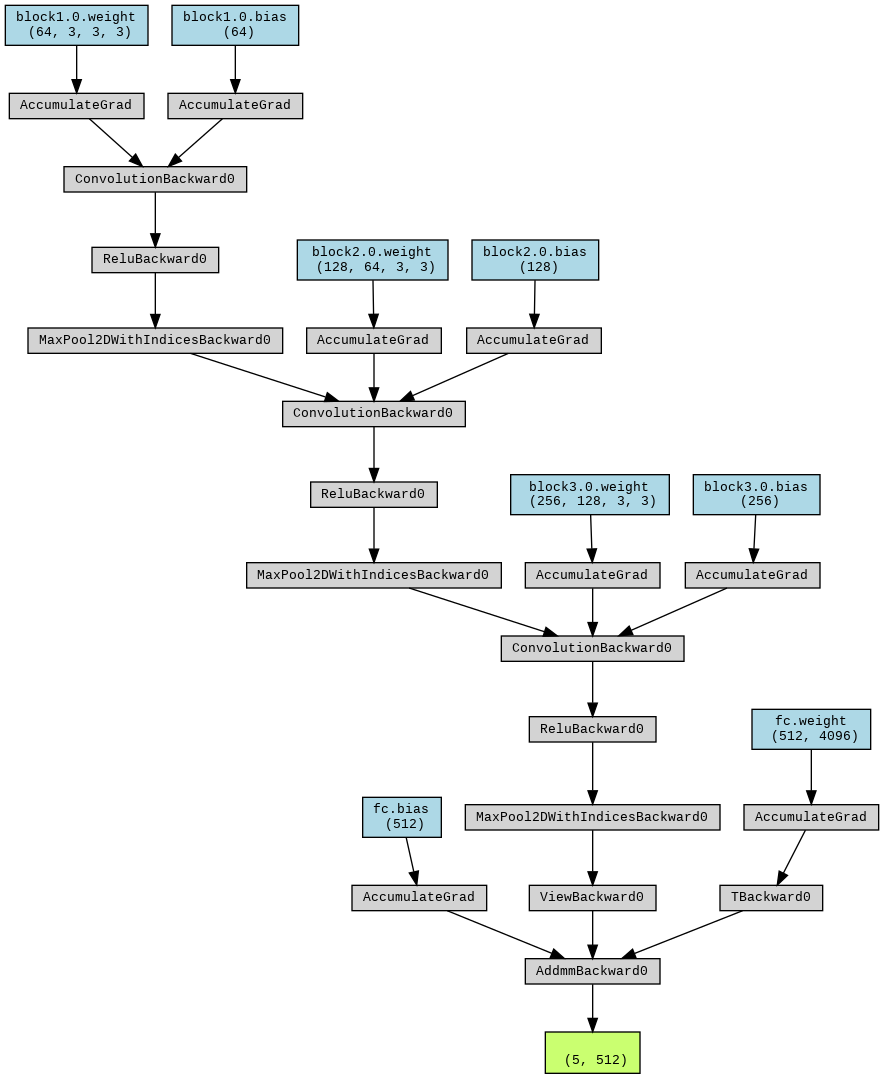

In [ ]:
# Visualizing the CNN based on 5 items in the training set
from torchviz import make_dot

images = torch.stack([trainset[i][0] for i in range(5)])
images = images.to(device)
y = model_basic(images)
dot = make_dot(y, params=dict(model_basic.named_parameters()))
dot.render("model_basic_architecture", format="png")

from IPython.display import Image
display(Image(filename="model_basic_architecture.png"))

## 2.4 Compiling Model With Loss Function and Optimizer




*   **Loss Function:** Cross Entropy Loss: Compares the true class with the probabilities and penalizes the confident wrong predictions. It essentially tries to maximize the probability of the true class by minimizing the probability of the classes that are not true.
*   **Optimizer:** Adam: Automatically adjusts learning rates and keeps track of past gradients. Generally leads to fast and stable convergence with minimal tuning required.



In [ ]:
# Defining the loss function and Optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_basic.parameters(), lr=0.001)

## 2.5 Training the Model

In [ ]:
# Setting this hyperparameter as static number for basic CNN model
num_epochs = 10

In [ ]:
# Training Loop:
def train_function(model, train_loader, val_loader, num_epochs, loss_function, optimizer, device, use_early_stopping = False, patience=3):

  train_losses, val_losses = [], []
  train_accs, val_accs = [], []
  val_precision, val_recalls, val_f1s = [], [], []

  if use_early_stopping:
    best_val_loss = float('inf')
    counter = 0
    best_model_weights = copy.deepcopy(model.state_dict())

  # For each epoch, train the model and record the scores, at the end of the epoch test against the validation set.
  for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
      images, labels = images.to(device), labels.to(device)
      optimizer.zero_grad()

      outputs = model(images)
      loss = loss_function(outputs, labels)

      loss.backward()
      optimizer.step()

      train_loss += loss.item()

      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()

    train_acc = correct / total
    train_losses.append(train_loss/ len(train_loader))
    train_accs.append(train_acc)

    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
      for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = loss_function(outputs, labels)

        val_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    val_loss_avg = val_loss / len(val_loader)
    val_acc = correct / total
    precision = precision_score(all_labels, all_preds, average='macro')
    recall = recall_score(all_labels, all_preds, average='macro')
    f1 = f1_score(all_labels, all_preds, average='macro')

    val_losses.append(val_loss/ len(val_loader))
    val_accs.append(val_acc)
    val_precision.append(precision)
    val_recalls.append(recall)
    val_f1s.append(f1)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss: .4f}, Train Acc: {100*train_acc: .2f}%")
    print(f"Val Loss: {val_loss: .4f}, Val Acc: {100*val_acc: .2f}%")
    print(f"Precision: {precision: .2f}, Recall: {recall: .2f}, F1: {f1: .2f}")
    print("-"*50)


    if use_early_stopping:
      if val_loss_avg < best_val_loss:
        best_val_loss = val_loss_avg
        counter = 0
        best_model_weights = copy.deepcopy(model.state_dict())
      else:
        counter += 1
        print(f"No Improvement. Patience: {counter}/{patience}")
        print("-"*50)

        if counter >= patience:
          print("Early Stopping")
          break

  if use_early_stopping:
    model.load_state_dict(best_model_weights)

  return {
      "train_losses": train_losses,
      "val_losses": val_losses,
      "train_accs": train_accs,
      "val_accs": val_accs,
      "val_precision": val_precision,
      "val_recalls": val_recalls,
      "val_f1s": val_f1s
  }

In [ ]:
# Calling the training function
training_results = train_function(
    model = model_basic,
    train_loader = train_loader,
    val_loader = val_loader,
    num_epochs = num_epochs,
    loss_function = loss_fn,
    optimizer = optimizer,
    device = device)

Epoch 1/10
Train Loss:  548.2422, Train Acc:  45.50%
Val Loss:  46.2732, Val Acc:  58.40%
Precision:  0.59, Recall:  0.58, F1:  0.58
--------------------------------------------------
Epoch 2/10
Train Loss:  354.2708, Train Acc:  64.85%
Val Loss:  35.8676, Val Acc:  68.34%
Precision:  0.69, Recall:  0.68, F1:  0.68
--------------------------------------------------
Epoch 3/10
Train Loss:  281.9565, Train Acc:  72.43%
Val Loss:  32.6082, Val Acc:  70.88%
Precision:  0.73, Recall:  0.71, F1:  0.71
--------------------------------------------------
Epoch 4/10
Train Loss:  233.7917, Train Acc:  76.90%
Val Loss:  31.3559, Val Acc:  72.68%
Precision:  0.74, Recall:  0.73, F1:  0.72
--------------------------------------------------
Epoch 5/10
Train Loss:  199.8496, Train Acc:  80.52%
Val Loss:  27.3687, Val Acc:  76.08%
Precision:  0.76, Recall:  0.76, F1:  0.76
--------------------------------------------------
Epoch 6/10
Train Loss:  168.1423, Train Acc:  83.47%
Val Loss:  28.1324, Val Acc

## 2.6 Visualizing Training Process

In [ ]:
# Separating the results for easier visualizations:
train_losses = training_results["train_losses"]
val_losses = training_results["val_losses"]
train_accs = training_results["train_accs"]
val_accs = training_results["val_accs"]
val_precision = training_results["val_precision"]
val_recalls = training_results["val_recalls"]
val_f1s = training_results["val_f1s"]

### 2.6.2 Plotting Loss

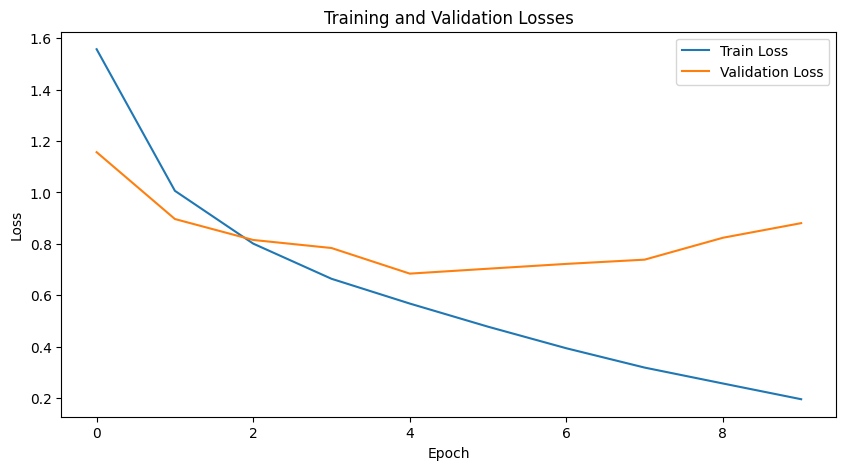

In [ ]:
# Plotting the Losses
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title("Training and Validation Losses")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

The above plot shows how the training and validation loss change across the epochs. As it can be seen the training loss starts high and decreases steadily as the epochs increase. Eventually the training loss drops below 0.2. The validation loss starts moderate, starts decreasig, and then increases. The increase is likely contributed to the model becoming overfit on the training data. At epoch 5, the training loss decreases while the validation loss starts increasing.

### 2.6.2 Plotting Accuracy

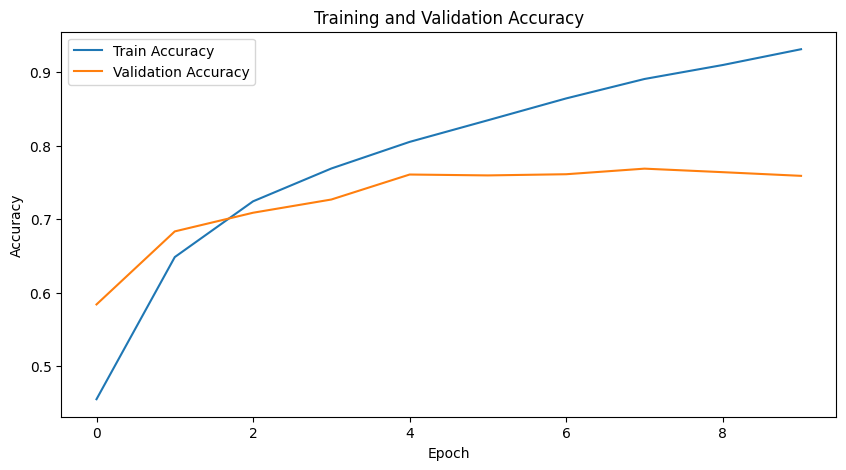

In [ ]:
# Accuracy Plot:
plt.figure(figsize=(10, 5))
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

This plot shows the opposite aspect of the previous plot and focuses on the accuracy. The training accuracy starts low, and eventually increases to well above 0.9. The validation loss starts at around 0.6 and increases before flattening neat 0.75. As mentioned before, this can likely be contributed to the model starting to overfit to the data in training.

### 2.6.3 Plotting Precision, Recall, and F1

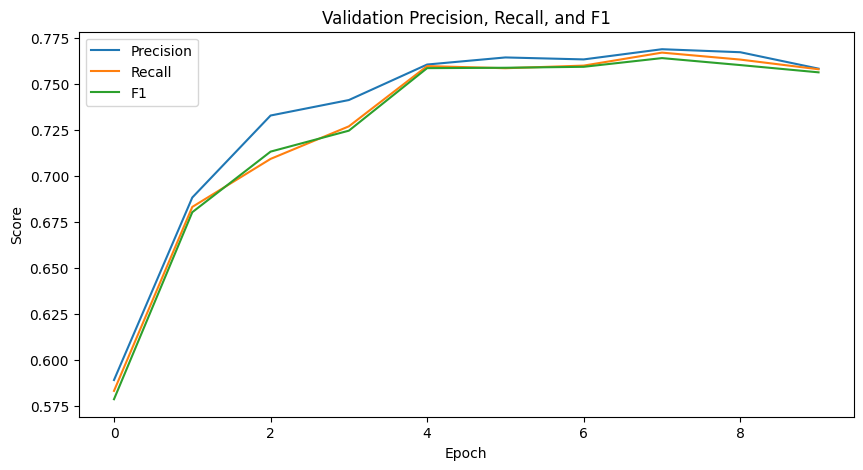

In [ ]:
# Precision, Recall, and F1 from Validation Plot
plt.figure(figsize=(10, 5))
plt.plot(val_precision, label="Precision")
plt.plot(val_recalls, label="Recall")
plt.plot(val_f1s, label="F1")
plt.title("Validation Precision, Recall, and F1")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.show()

Precision, Recall, and F1 focus on more of a class level as compared to accuracy scores. However, they seem to follow the same distribution as the accuracy from the previous plot. They start low and eventually increase to about 0.75.

# Step 3: Model Evaluation

In [ ]:
# Predict Labels for the Test Set

def test_prediction(model, device, test_loader):
  model.eval()

  all_preds = []
  all_labels = []

  with torch.no_grad():
    for images, labels in test_loader:
      images, labels = images.to(device), labels.to(device)
      outputs = model(images)
      _, predicted = torch.max(outputs.data, 1)

      all_preds.extend(predicted.cpu().numpy())
      all_labels.extend(labels.cpu().numpy())

  return all_preds, all_labels

In [ ]:
# Computing the Performance Metrics
def compute_metrics(all_preds, all_labels):
  accuracy = accuracy_score(all_labels, all_preds)
  precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
  recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
  f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

  print(f"Test Accuracy: {accuracy: .4f}")
  print(f"Test Precision: {precision: .4f}")
  print(f"Test Recall: {recall: .4f}")
  print(f"Test F1: {f1: .4f}")

  return accuracy, precision, recall, f1

In [ ]:
# Confusion Matrix
def plot_confusion_matrix(all_preds, all_labels):
  cm = confusion_matrix(all_labels, all_preds)
  cm_percent = cm.astype('float') / cm.sum(axis=1, keepdims=True)

  plt.figure(figsize=(10, 8))
  sns.heatmap(cm_percent, annot=True, cmap='Blues')
  plt.xlabel('Predicted')
  plt.ylabel('True')
  plt.title('Confusion Matrix')
  plt.show()

## 3.1 Predicting Labels on Test Set

In [ ]:
# Predicting the Labels on the Test set
all_preds, all_labels = test_prediction(model_basic, device, test_loader)

## 3.2 Computing the Performance Metrics

In [ ]:
# Computing the Performance Metrics
accuracy, precision, recall, f1 = compute_metrics(all_preds, all_labels)

Test Accuracy:  0.7608
Test Precision:  0.7625
Test Recall:  0.7608
Test F1:  0.7593


## 3.3 Confusion Matrix

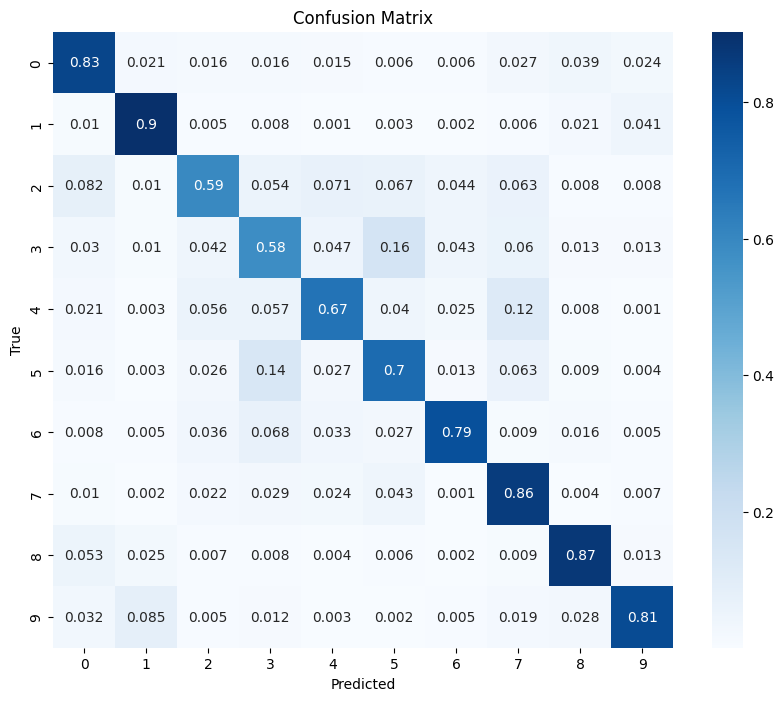

In [ ]:
plot_confusion_matrix(all_preds, all_labels)

## 3.4 Analyze Results

### 3.4.1 Performance Results

**Best Performance Metric for Model Choice:**  

For model evaluation, the best options would be accuracy and a secondary metric of macro F1-score. For this dataset, we do not have to consider class imbalances because every class has the same volume of data. Therefore, accuracy would provide a good view into how the model is performing across all classes and is easy to interpret. For a secondary metric, macro F1 would give an in depth view of how each class is performing. It takes the scores of each class equally, so if one particular class is performing poorly it is easier to recognize in macro F1.

**Perfomance Metrics**


Based on the performance metrics, we can see that the model is semi-well on unseen data. The accuracy of 75.79% shows that the model was able to correctly classify 75% of the data instances. The precision (76.47%) and recall (75.79%) show the model was able to classify the correct classes most of the time. Finally, the Macro F1 of 75.69% means the model was able to perform well at the class level. Overall, the performance metrics show the basic model is able to corretly classify a lot of the instances, but can be improved on.

**Confusion Matrix**

The majority of the classes seemed to perform reasonably well. Classes 8 and 9 were even identified correctly over 90% of the time. However, some of the classes were often misclassified including Classes 2 and 3 which were only correct in 61% of instances.

This is likely due to the low 32×32 resolution making it difficult to distinguish fine details. This pattern aligns with the heatmap from Section 1.2.5, which showed animal classes clustering together with high similarity scores. Overall, the vehicle classes outperformed the animal classes



### 3.4.2 Potential Improvements

In order to improve the model performane there are several techniques that can be tried:

---

**Architecture Changes:**



*   Adding more layers and making the network deeper could allow the model to differentiate between classes more extensively.
*   Differing activation functions might be able to adapt to the nonlinearities of them model more closely to the actual data relationships.
*   Chaning the order of the layers/ configurations could change the way the model is processing and developing the relationships.

---

**Regularization:**

Currently the training accuracy is 17% higher than the test accuracy, which suggest the model could be overfit. In order to improve the generalization of the model redularization techniques can be experimented with.


*   Dropout: Randomly drops some of the nodes during training to prevent over dependence on specific parts of the model.
*   L2 Regularization: Penalizes weights that are too large to ensure the model does not become too dependent on specific connections.
---

**Data Augmentations:**

There are several transformations that can be added to the training data to increase the variance and generalize the model better.

*   RandomHorizontalFlip: Flips images horizontally with a 50% probability to introduce more noice into the dataset.
*   RandomCrop: Randomly crops certain images to introduce noise.
* ColorJitter: Affects certain aspects of the images like brightness, contrast, and saturation to introduce noise.
*   RandomRotation: Slightly rotates images.



---

**Hyperparameter Tuning**

Currently the hyperparameters were chosen and set manually. However, batch size, epochs, and learning rate could all affect the model performance and need to be tuned. In order to tune these we should use RandomSearch to efficiently test different hyperparameter combinations. The hyperparameters we will be testing are: dropout in the convolutional layers, dropout in the final layers, learning rate, and batch size. Once those have been tested and the best options are chosen, we will test various epoch sizes. For epoch size testing, we will use early stopping and patience. This will keep track of the validation losses, and if there is more than 3 epochs in a rows without any improvement it will stop the training to prevent further overfitting.


# Step 4: Model Improvement

## 4.1 Architecture Changes


Additional Layers Added:

*   **Dropout:** Randomly “drops” neurons during training to prevent the model from becoming too dependent on one layer or neuron. By removing randomly, the model learns more robustly and generalizes better.
*   **BatchNorm:** Normalizes the outputs of the layers. The normalization makes the model more stable by preventing values from becoming too large or too small. It also allows the model to converge faster and reduces some of the sensitivity to the initialization.

In [ ]:

class CIFAR10_CNN(nn.Module):
  def __init__(self, dropout_conv, dropout_fc):
    super(CIFAR10_CNN, self).__init__()

    # Block 1:
    self.block1 = nn.Sequential(
        nn.Conv2d(3,64, kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.Conv2d(64,64, kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Dropout(dropout_conv)
    )


    # Block 2:
    self.block2 = nn.Sequential(
        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.Conv2d(128, 128, kernel_size=3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Dropout(dropout_conv)
    )

    # Block 3:
    self.block3 = nn.Sequential(
        nn.Conv2d(128,256, kernel_size=3, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(),
        nn.Conv2d(256,256, kernel_size=3, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Dropout(dropout_conv)
    )

    # Fully Connected Layer
    self.fc = nn.Linear(256*4*4, 512)
    self.bn_fc = nn.BatchNorm1d(512)
    self.dropout_fc = nn.Dropout(dropout_fc)
    self.fc_out = nn.Linear(512, 10)

  def forward(self, x):
    x = self.block1(x)
    x = self.block2(x)
    x = self.block3(x)
    x = torch.flatten(x,1)
    x = self.fc(x)
    x = self.bn_fc(x)
    x = F.relu(x)
    x = self.dropout_fc(x)
    x = self.fc_out(x)
    return x

4.2 Regularization

Since the basic model showed clear signs of overfitting, we added two regularization techniques.

**Dropout** randomly turns off a percentage of neurons during training, so the model can't just memorize patterns. We applied it after each convolutional block and after the fully connected layer.

**Batch Normalization** normalizes the outputs between layers, which keeps training more stable.

## 4.3 Data Augmentation

In [ ]:
# Data Augmentation
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=train_transform)
valset = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=basic_test_transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=False, transform=basic_test_transform)

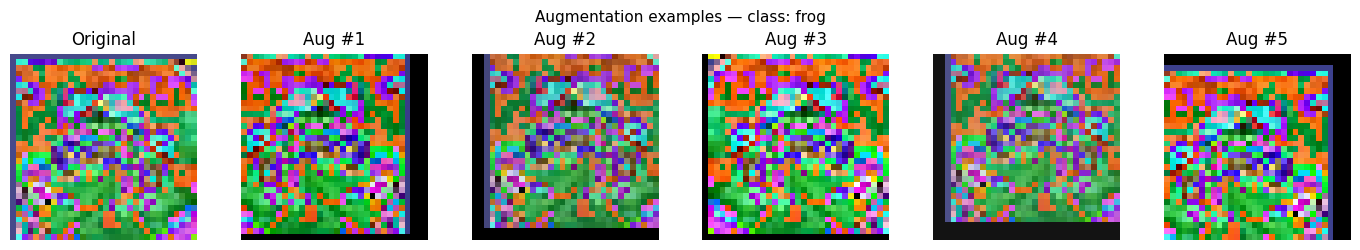

In [ ]:
# Visualizing some of the Image Transformations to show how they differ
aug_only = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
])
orig, label = trainset[0]
orig = transforms.ToPILImage()(orig)

fig, axes = plt.subplots(1, 6, figsize=(14, 2.5))
axes[0].imshow(orig); axes[0].set_title('Original'); axes[0].axis('off')
for i in range(1, 6):
    axes[i].imshow(aug_only(orig))
    axes[i].set_title(f'Aug #{i}')
    axes[i].axis('off')
plt.suptitle(f'Augmentation examples — class: {trainset.classes[label]}', fontsize=11)
plt.tight_layout()
plt.show()

## 4.4 Hyperparameter Testing

To fine-tune the hyperparameters, a random search approach was used across 10 trials. For each trial, a random combination of learning rate, batch size, and dropout rates were picked from a predefined parameter space and trained for 5 epochs. The best combination was then chosen based on whichever trial achieved the highest validation accuracy.

In [ ]:
# Setting up Hyperparameters for testing:
param_space = {
    "lr": [1e-3, 5e-4, 1e-4],
    "batch_size": [32, 64, 128],
    "dropout_conv": [0.2, 0.25, 0.3],
    "dropout_fc": [0.4, 0.5, 0.6]
}

In [ ]:
# Function to run the hyperparameters through 5 epochs and return the best achieved validation accuracy
def hyp_train_function(model, train_loader, val_loader, num_epochs, loss_function, optimizer, device, n_epochs):
  best_val_acc = 0.0

  for epoch in range(n_epochs):
      model.train()
      for images, labels in train_loader:
          images, labels = images.to(device), labels.to(device)
          optimizer.zero_grad()
          outputs = model(images)
          loss = loss_function(outputs, labels)
          loss.backward()
          optimizer.step()

      # Evaluation on validation set
      model.eval()
      correct, total = 0, 0
      with torch.no_grad():
        for images, labels in val_loader:
          images, labels = images.to(device), labels.to(device)
          outputs = model(images)
          _, predicted = outputs.max(1)
          total += labels.size(0)
          correct += (predicted == labels).sum().item()
      val_acc = correct / total

      if val_acc > best_val_acc:
        best_val_acc = val_acc

  return best_val_acc

In [ ]:
# Testing various hyperparameters
num_trials = 10
best_accuracy = 0
best_params = None

for trial in range(num_trials):
  # Choosing the random parameters
  lr = random.choice(param_space["lr"])
  batch_size = random.choice(param_space["batch_size"])
  dropout_conv = random.choice(param_space["dropout_conv"])
  dropout_fc = random.choice(param_space["dropout_fc"])

  # Defining the Loaders again with batch size
  train_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
  val_loader = torch.utils.data.DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=2)

  # Defining the model and optimizer again
  model = CIFAR10_CNN(dropout_conv, dropout_fc).to(device)
  optimizer = torch.optim.Adam(model.parameters(), lr=lr)

  # Keeping the number of epochs low for the hyperparameter testing
  n_epochs = 5
  trial_acc = hyp_train_function(model, train_loader, val_loader, num_epochs, loss_fn, optimizer, device, n_epochs)

  print("-"*50)
  print(f"Combination: {trial+1}")
  print(f"\nHyperparameters: \nLR: {lr}\nBatch Size: {batch_size}\nDrouput Conv: {dropout_conv}\nDropout FC: {dropout_fc}")
  print(f"\nAccuracy: {trial_acc}")

  if trial_acc > best_accuracy:
    best_accuracy = trial_acc
    best_params = {
                "lr": optimizer.param_groups[0]['lr'],
                "batch_size": train_loader.batch_size,
                "dropout_conv": model.block1[3].p if isinstance(model.block1[3], nn.Dropout) else None,
                "dropout_fc": model.dropout_fc.p if hasattr(model, 'dropout_fc') else None}

print("\n\nBest Hyperparameters Found:")
print(best_params)
print(f"Best Validation Accuracy: {best_accuracy:.4f}")

--------------------------------------------------
Combination: 1

Hyperparameters: 
LR: 0.0001
Batch Size: 32
Drouput Conv: 0.2
Dropout FC: 0.6

Accuracy: 0.7807
--------------------------------------------------
Combination: 2

Hyperparameters: 
LR: 0.0005
Batch Size: 32
Drouput Conv: 0.2
Dropout FC: 0.4

Accuracy: 0.82592
--------------------------------------------------
Combination: 3

Hyperparameters: 
LR: 0.0001
Batch Size: 32
Drouput Conv: 0.3
Dropout FC: 0.6

Accuracy: 0.7483
--------------------------------------------------
Combination: 4

Hyperparameters: 
LR: 0.0001
Batch Size: 32
Drouput Conv: 0.3
Dropout FC: 0.5

Accuracy: 0.75892
--------------------------------------------------
Combination: 5

Hyperparameters: 
LR: 0.001
Batch Size: 32
Drouput Conv: 0.2
Dropout FC: 0.4

Accuracy: 0.80992
--------------------------------------------------
Combination: 6

Hyperparameters: 
LR: 0.001
Batch Size: 128
Drouput Conv: 0.3
Dropout FC: 0.4

Accuracy: 0.79342
-------------------

# Final Model

## Training

In [ ]:
# Training the Final Model:
dropout_conv = best_params["dropout_conv"] or 0.0
dropout_fc = best_params["dropout_fc"] or 0.0
model_final = CIFAR10_CNN(dropout_conv=dropout_conv, dropout_fc=dropout_fc).to(device)
optimizer = torch.optim.Adam(model_final.parameters(), lr=best_params["lr"], weight_decay=1e-4)

final_results = train_function(
    model = model_final,
    train_loader = train_loader,
    val_loader = val_loader,
    num_epochs = 100,
    loss_function = loss_fn,
    optimizer = optimizer,
    device = device,
    use_early_stopping = True,
    patience = 3
)

# The epochs is set to 100 so that the model is able to grow as long as the patience allows.

Epoch 1/100
Train Loss:  525.1913, Train Acc:  51.53%
Val Loss:  380.0053, Val Acc:  65.07%
Precision:  0.68, Recall:  0.65, F1:  0.65
--------------------------------------------------
Epoch 2/100
Train Loss:  364.5598, Train Acc:  67.14%
Val Loss:  272.3184, Val Acc:  75.31%
Precision:  0.77, Recall:  0.75, F1:  0.75
--------------------------------------------------
Epoch 3/100
Train Loss:  308.5397, Train Acc:  72.51%
Val Loss:  244.0579, Val Acc:  78.37%
Precision:  0.79, Recall:  0.78, F1:  0.78
--------------------------------------------------
Epoch 4/100
Train Loss:  277.4423, Train Acc:  75.36%
Val Loss:  231.0153, Val Acc:  79.29%
Precision:  0.81, Recall:  0.79, F1:  0.79
--------------------------------------------------
Epoch 5/100
Train Loss:  253.9611, Train Acc:  77.31%
Val Loss:  203.0856, Val Acc:  81.75%
Precision:  0.83, Recall:  0.82, F1:  0.82
--------------------------------------------------
Epoch 6/100
Train Loss:  233.7207, Train Acc:  79.11%
Val Loss:  176.4

## Predictions Against Test Set


In [ ]:
# Getting the test predictions
all_preds, all_labels = test_prediction(model_final, device, test_loader)

In [ ]:
# Computing the Testing Metrics
accuracy, precision, recall, f1 = compute_metrics(all_preds, all_labels)

Test Accuracy:  0.8865
Test Precision:  0.8867
Test Recall:  0.8865
Test F1:  0.8859


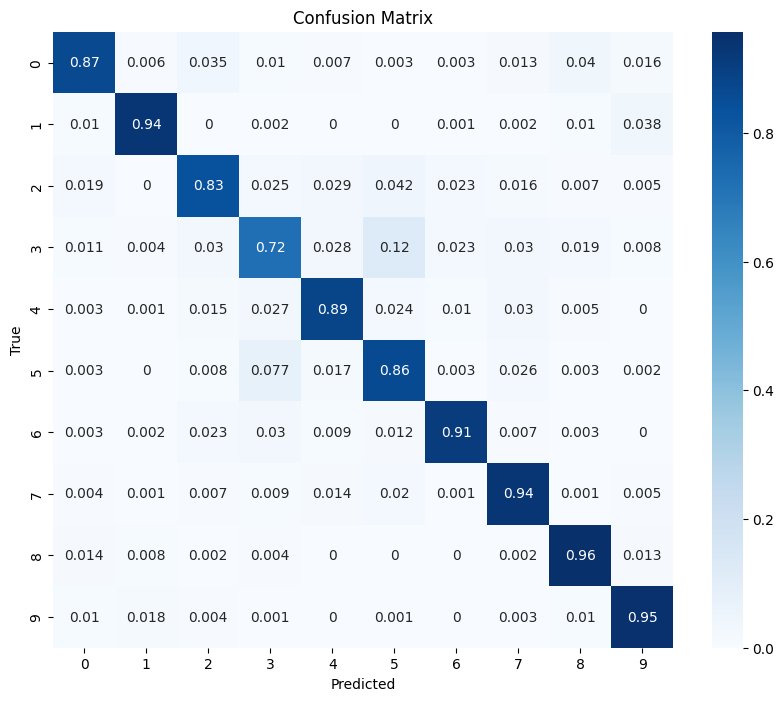

In [ ]:
# Plotting the Confusion Matrix
plot_confusion_matrix(all_preds, all_labels)

The confusion matrix shows strong scores across all classes. The lowest scoring class was Class 3 - Cat which was still predicted correctly in 72% of instances. On the other hand, 5 of the 10 classes scored above 90%.

# Comparing the Basic Model and Fine Tuned Models

In Step 2 we defined, trained, and evaluated a basic CNN model with little to no fine-tuning. In Step 4, we fine-tune the CNN model to be better suited for the dataset. This included a variety of things like architecture changes, regularization, data augmentation, and hyperparameter tuning. Below we will discuss the effects of the model improvements:

|         | Basic CNN | Final Model |
|-------- | --------- | ----------- |
| Accuracy | 76.08%   | 88.65%      |
| Precision | 76.25%  | 88.67%      |
| Recall   | 76.08%   | 88.65%      |
| F1      | 75.93%    | 88.59%      |


As shown in the table above the final model with fine-tuning was able to perform 12% better in accuracy than the basic model. It also outscores the basic models in all other categories as well. Therefore, the model improvements helped strengthen the model and increase the generalization abilities.